In [ ]:
# Imported Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import time

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import collections


# Other Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold
import warnings
warnings.filterwarnings("ignore")


In [ ]:
df = pd.read_csv('/content/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.isnull().sum().max()

0

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

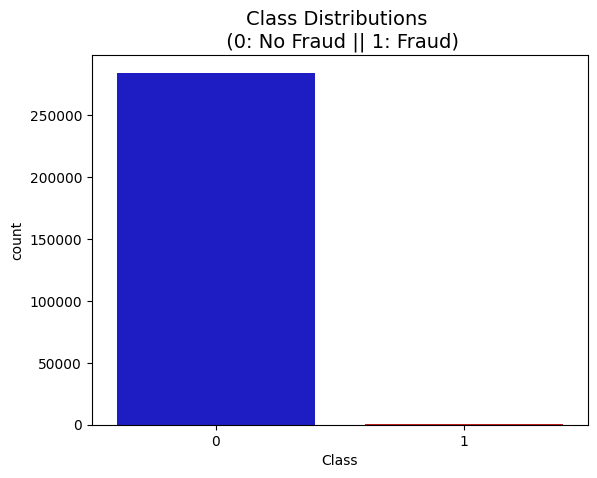

In [ ]:
colors = ['#0101DF', '#DF0101']

sns.countplot(x = 'Class', data=df, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

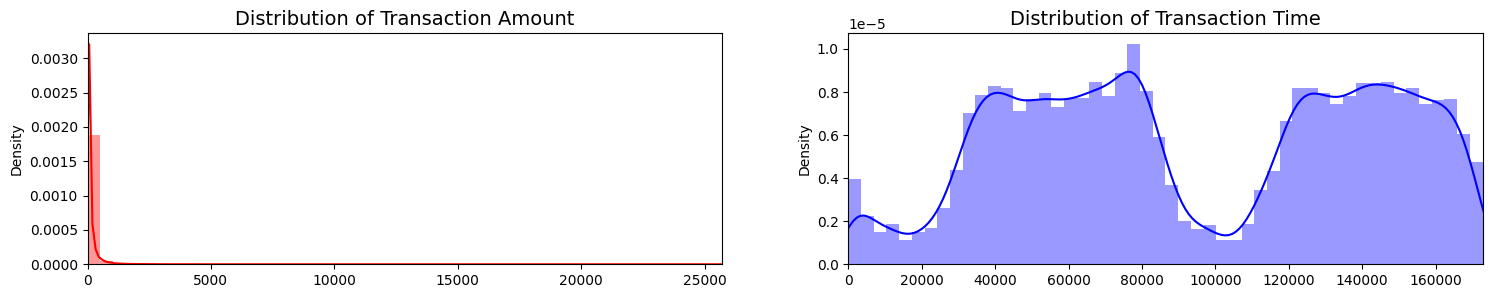

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18,3))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])



plt.show()

In [ ]:
#Time and Amount scaling
from sklearn.preprocessing import StandardScaler, RobustScaler

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

In [ ]:
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)
df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


# **Splitting the Data (Original DataFrame)**




In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

X = df.drop('Class', axis=1)
y = df['Class']

sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

for train_index, test_index in sss.split(X, y):
    print('Train:', train_index, 'Test:', test_index)
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

    # Check the Distributions of the labels

    # Turn into an array
    original_Xtrain = original_Xtrain.values
    original_Xtest = original_Xtest.values
    original_ytrain = original_ytrain.values
    original_ytest = original_ytest.values

    # See if both the train and test label distribution are similarly distributed
    train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
    test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)
    print('-' * 100)

    print('Label Distributions: \n')
    print(train_counts_label/ len(original_ytrain))
    print(test_counts_label/ len(original_ytest))

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset
Train: [ 30473  30496  31002 ... 284804 284805 284806] Test: [    0     1     2 ... 57017 57018 57019]
----------------------------------------------------------------------------------------------------
Label Distributions: 

[0.99827514 0.00172486]
[0.998262 0.001738]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 30473  30496  31002 ... 113964 113965 113966]
----------------------------------------------------------------------------------------------------
Label Distributions: 

[0.99827514 0.00172486]
[0.998262 0.001738]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 81609  82400  83053 ... 170946 170947 170948]
----------------------------------------------------------------------------------------------------
Label Distributions: 

[0.99827076 0.00172924]
[0.99827952 0.00172048]
Train: [     0      1      2 ... 284804 284805 284806] Test: [150654 150660 150661 ... 227866 227867 227868]


**Stratified K-Folds Cross-Validation:**
Purpose: The key idea behind using StratifiedKFold is to ensure that each fold (both the training and test sets) has the same proportion of classes (fraud and non-fraud transactions) as the original dataset. This is particularly useful for imbalanced datasets like credit card fraud detection, where fraudulent transactions are very rare compared to non-fraudulent ones.


In [ ]:
# Since our classes are highly skewed we should make them equivalent in order to have a normal distribution of the classes.

# Lets shuffle the data before creating the subsamples

df = df.sample(frac=1)

# amount of fraud classes 492 rows.
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Shuffle dataframe rows
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
260868,-0.239503,0.881907,-0.128953,0.926574,-1.780182,-1.577483,3.054415,3.382939,0.099527,0.136024,...,-0.119546,0.427482,-1.166794,0.225045,0.578597,-0.404621,0.170528,0.282231,0.077919,0
102446,-0.293440,-0.193670,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,...,-3.493050,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1
84467,-0.043038,-0.286317,-1.776768,2.083956,1.642512,2.998628,-0.996515,1.270954,-1.466265,-2.361088,...,-0.621830,3.263407,-0.172293,0.346074,0.372453,-0.324810,0.385710,0.499874,0.157445,0
124036,1.495144,-0.088558,-0.715414,0.608590,1.155501,-0.267565,-0.563748,-0.618898,0.698308,0.069837,...,-0.186978,0.130749,0.239389,-0.090227,0.411572,-0.216126,0.353896,-0.062361,0.008433,1
140786,-0.293440,-0.008905,-0.433222,2.428379,-3.996454,4.871299,-1.796308,-0.586868,-4.654543,1.285230,...,0.745029,0.713559,-0.408954,-0.320890,-0.804230,0.962852,0.199558,1.094533,0.541148,1


In [ ]:
new_df.tail()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
221018,4.164186,0.677898,-3.367770,0.099249,-6.148487,3.401955,0.458307,-1.571630,-1.358708,0.672409,...,0.264699,0.861308,1.249301,1.850627,-0.117471,1.219815,0.000251,1.036011,0.004367,1
226877,-0.307413,0.706622,-6.423306,1.658515,-5.866440,2.052064,-0.615817,-3.372266,-5.036556,2.643106,...,-0.713516,0.641211,-0.256678,-2.337233,-0.158278,1.198797,-0.261258,0.780125,-0.731801,1
163373,-0.274436,0.366428,2.122619,-0.178570,-1.861970,-0.002650,0.534019,-0.419736,0.146300,-0.218226,...,-0.178961,0.316245,1.135272,-0.244276,-0.916399,0.450764,1.052937,-0.099083,-0.100136,0
64460,1.089779,-0.394001,-11.205461,7.914633,-13.987752,4.333341,-8.484970,-3.506561,-8.935243,7.704449,...,0.860912,0.942593,-0.987848,-0.279446,-0.027299,0.644344,-0.263078,1.084023,0.211933,1
191544,0.823028,0.524160,0.054682,1.856500,-4.075451,4.100098,-0.800931,-0.292502,-2.317431,1.189747,...,0.509559,0.618248,0.800932,0.130016,0.288946,-0.366658,0.030307,0.431182,0.110698,1


In [ ]:
len(new_df)

984

Distribution of te Classes in the subsample dataset
Class
0    0.5
1    0.5
Name: count, dtype: float64


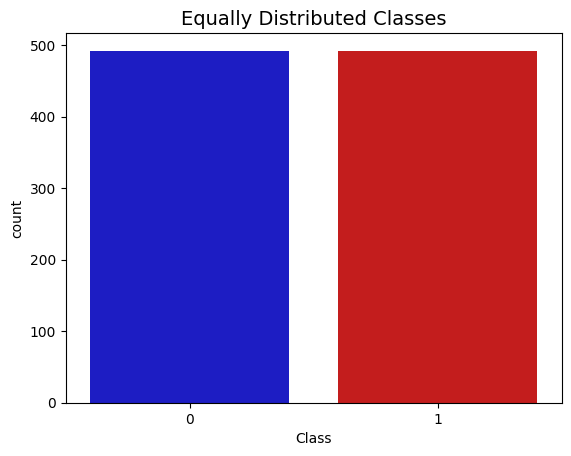

In [ ]:
print('Distribution of te Classes in the subsample dataset')
print(new_df['Class'].value_counts()/len(new_df))



sns.countplot(x='Class', data=new_df, palette=colors)
plt.title('Equally Distributed Classes', fontsize=14)
plt.show()

# **Correlation Matrices**



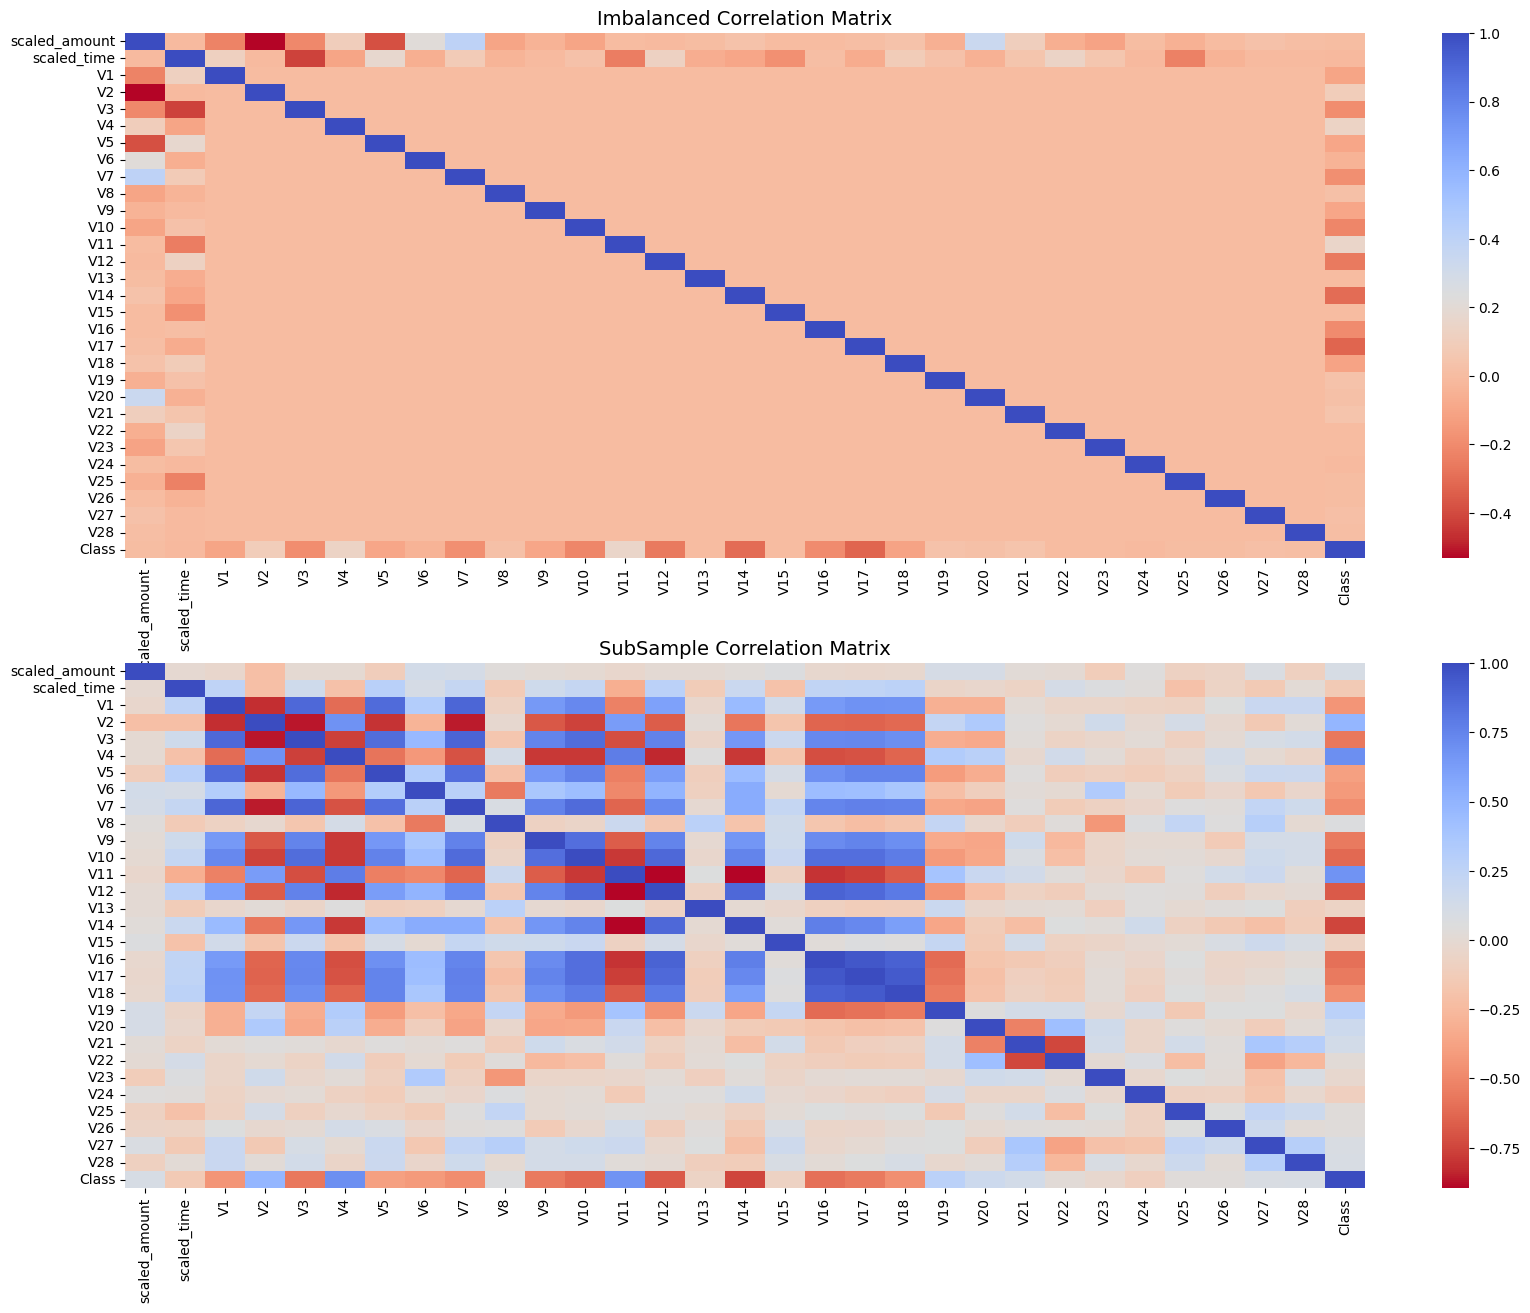

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 15))

# Entire DataFrame
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size': 10}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix", fontsize=14)

# Subsample DataFrame
sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size': 10}, ax=ax2)
ax2.set_title('SubSample Correlation Matrix', fontsize=14)

plt.show()
import IPython.display as display
display.display(plt.gcf())  # Forces rendering of the current figure



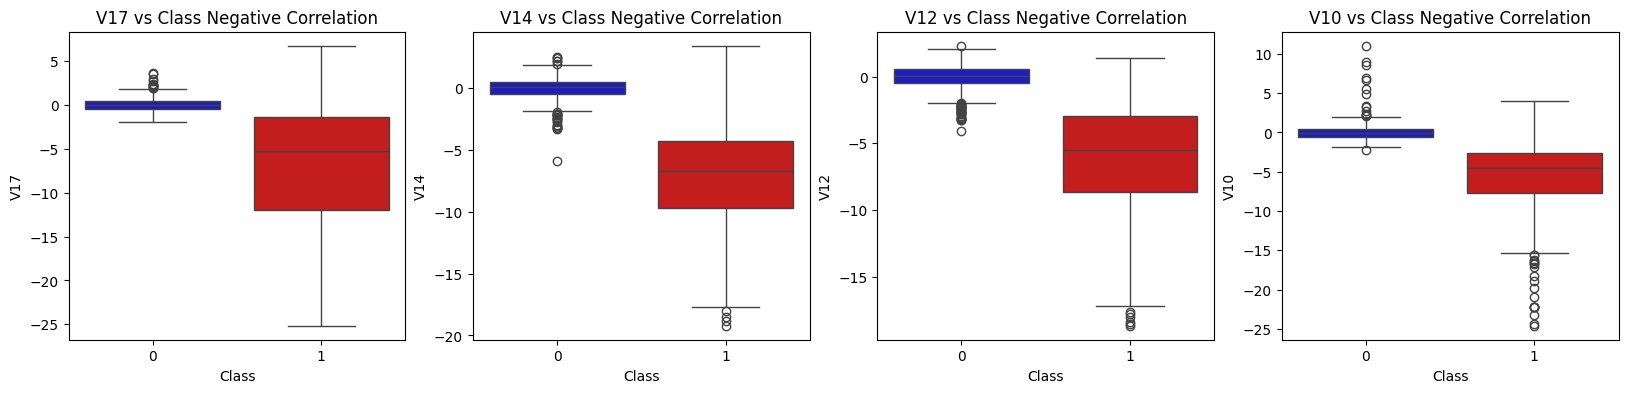

In [ ]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# Negative Correlations with our Class (The lower our feature value the more likely it will be a fraud transation)
sns.boxplot(x='Class', y='V17', data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V17 vs Class Negative Correlation')

sns.boxplot(x='Class', y='V14', data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V14 vs Class Negative Correlation')

sns.boxplot(x='Class', y='V12', data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V12 vs Class Negative Correlation')

sns.boxplot(x='Class', y='V10', data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V10 vs Class Negative Correlation')

plt.show()

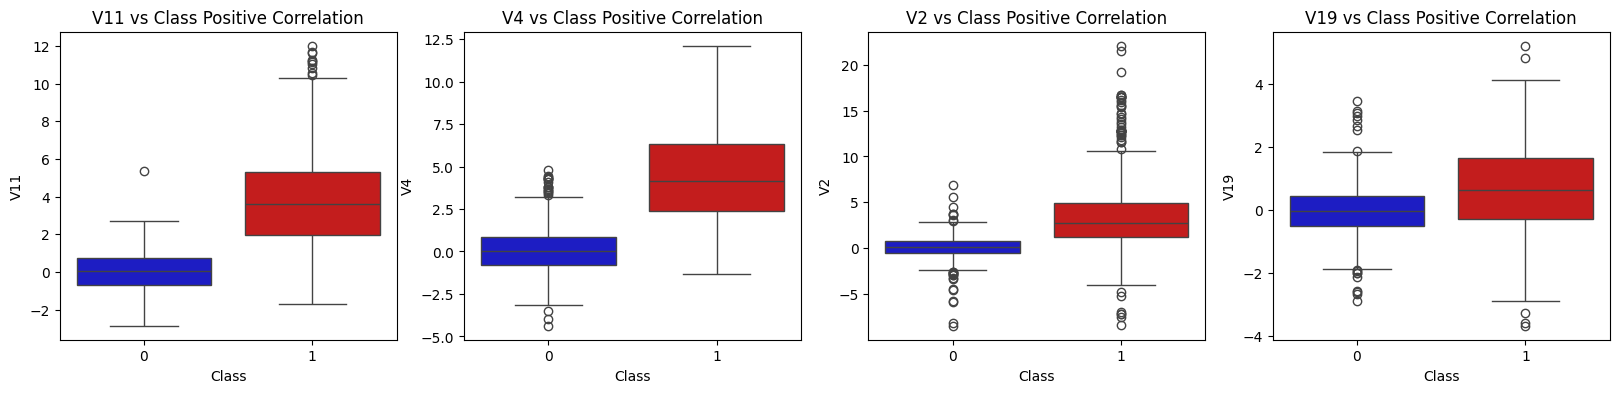

In [ ]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# Positive correlations
sns.boxplot(x="Class", y="V11", data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V11 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V4", data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V4 vs Class Positive Correlation')


sns.boxplot(x="Class", y="V2", data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V2 vs Class Positive Correlation')


sns.boxplot(x="Class", y="V19", data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V19 vs Class Positive Correlation')

plt.show()

In [ ]:
# # -----> V14 Removing Outliers (Highest Negative Correlated with Labels)
v14_fraud = new_df['V14'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
print('Quartile 25: {} | Quartile 75: {}'.format(q25, q75))
v14_iqr = q75 - q25
print('iqr: {}'.format(v14_iqr))

v14_cut_off = v14_iqr * 1.5
v14_lower, v14_upper = q25 - v14_cut_off, q75 + v14_cut_off
print('Cut Off: {}'.format(v14_cut_off))
print('V14 Lower: {}'.format(v14_lower))
print('V14 Upper: {}'.format(v14_upper))

outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
print('Feature V14 Outliers for Fraud Cases: {}'.format(len(outliers)))
print('V10 outliers:{}'.format(outliers))

new_df = new_df.drop(new_df[(new_df['V14'] > v14_upper) | (new_df['V14'] < v14_lower)].index)
print('----' * 44)

# -----> V12 removing outliers from fraud transactions
v12_fraud = new_df['V12'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v12_fraud, 25), np.percentile(v12_fraud, 75)
v12_iqr = q75 - q25

v12_cut_off = v12_iqr * 1.5
v12_lower, v12_upper = q25 - v12_cut_off, q75 + v12_cut_off
print('V12 Lower: {}'.format(v12_lower))
print('V12 Upper: {}'.format(v12_upper))
outliers = [x for x in v12_fraud if x < v12_lower or x > v12_upper]
print('V12 outliers: {}'.format(outliers))
print('Feature V12 Outliers for Fraud Cases: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['V12'] > v12_upper) | (new_df['V12'] < v12_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_df)))
print('----' * 44)


# Removing outliers V10 Feature
v10_fraud = new_df['V10'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25

v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off
print('V10 Lower: {}'.format(v10_lower))
print('V10 Upper: {}'.format(v10_upper))
outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print('V10 outliers: {}'.format(outliers))
print('Feature V10 Outliers for Fraud Cases: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['V10'] > v10_upper) | (new_df['V10'] < v10_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_df)))

Quartile 25: -9.692722964972386 | Quartile 75: -4.282820849486865
iqr: 5.409902115485521
Cut Off: 8.114853173228282
V14 Lower: -17.807576138200666
V14 Upper: 3.8320323237414167
Feature V14 Outliers for Fraud Cases: 4
V10 outliers:[-19.2143254902614, -18.8220867423816, -18.4937733551053, -18.0499976898594]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
V12 Lower: -17.3430371579634
V12 Upper: 5.776973384895937
V12 outliers: [-18.4311310279993, -18.5536970096458, -18.6837146333443, -18.0475965708216]
Feature V12 Outliers for Fraud Cases: 4
Number of Instances after outliers removal: 976
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
V10 Lower: -14.89885463232024
V10 Upper: 4.92033495834214
V10 outliers: [-20.9491915543611, -22.187088

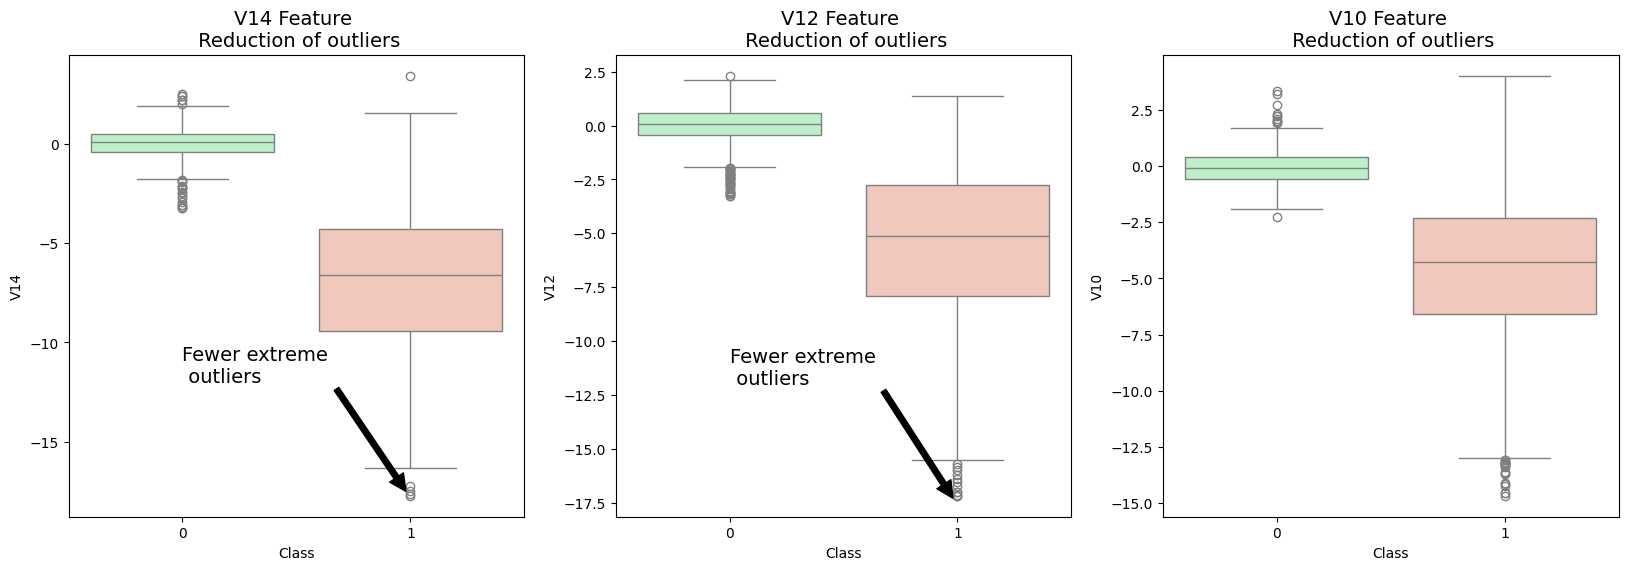

In [ ]:
# The purpose of the code is to visualize the reduction of outliers in the V14 feature after removing extreme values (outliers).
# It uses boxplots to compare the distribution of the V14 feature before and after outlier removal, focusing on fraudulent and non-fraudulent classes.
# The annotation helps to highlight that there are fewer extreme outliers after the data cleaning process.

f,(ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,6))

colors = ['#B3F9C5', '#f9c5b3']
# Boxplots with outliers removed
# Feature V14
sns.boxplot(x="Class", y="V14", data=new_df,ax=ax1, palette=colors)
ax1.set_title("V14 Feature \n Reduction of outliers", fontsize=14)
ax1.annotate('Fewer extreme \n outliers', xy=(0.98, -17.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)

# Feature 12
sns.boxplot(x="Class", y="V12", data=new_df, ax=ax2, palette=colors)
ax2.set_title("V12 Feature \n Reduction of outliers", fontsize=14)
ax2.annotate('Fewer extreme \n outliers', xy=(0.98, -17.3), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)

# Feature V10
sns.boxplot(x="Class", y="V10", data=new_df, ax=ax3, palette=colors)
ax3.set_title("V10 Feature \n Reduction of outliers", fontsize=14)
ax3.annotate('Fewer extreme \n outliers', xy=(0.95, -16.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)


plt.show()

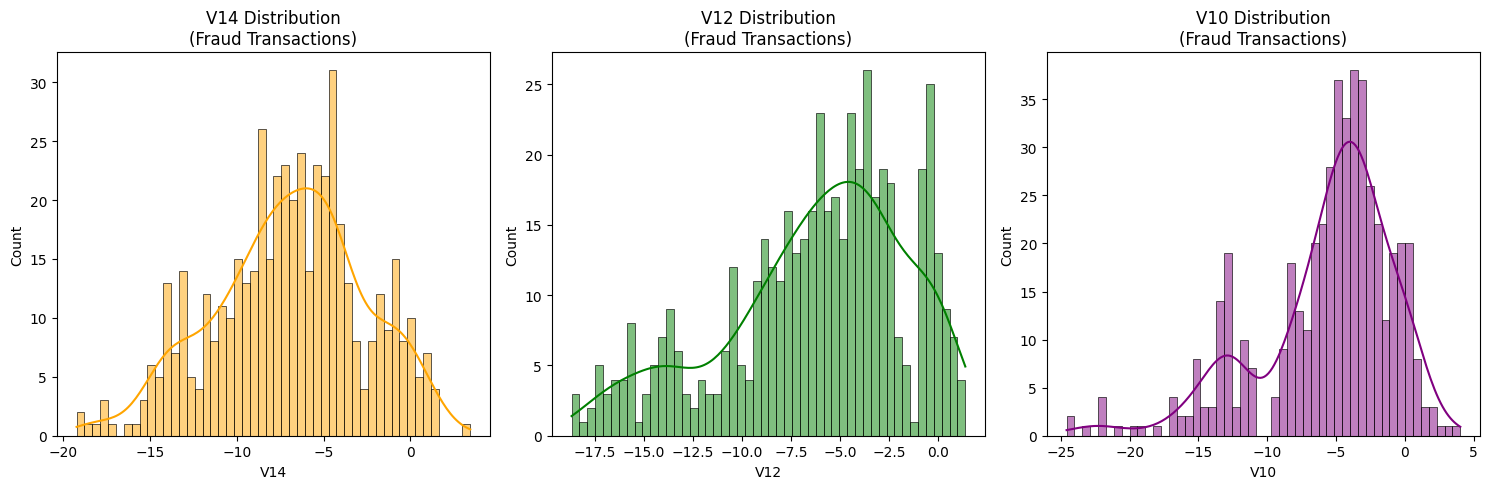

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size and styling
plt.figure(figsize=(15, 5))

# Plotting V14 Distribution
plt.subplot(1, 3, 1)
sns.histplot(df[df['Class'] == 1]['V14'], bins=50, kde=True, color='orange')
plt.title('V14 Distribution\n(Fraud Transactions)')

# Plotting V12 Distribution
plt.subplot(1, 3, 2)
sns.histplot(df[df['Class'] == 1]['V12'], bins=50, kde=True, color='green')
plt.title('V12 Distribution\n(Fraud Transactions)')

# Plotting V10 Distribution
plt.subplot(1, 3, 3)
sns.histplot(df[df['Class'] == 1]['V10'], bins=50, kde=True, color='purple')
plt.title('V10 Distribution\n(Fraud Transactions)')

plt.tight_layout()
plt.show()


In [ ]:
# new_df is from the random undersample data ( fewer instances )
X = new_df.drop('Class', axis=1)
y = new_df['Class']

# T-SNE Implementation
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print('T-SNE took {:.2} s'.format(t1 - t0))

# PCA Implementation
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print('PCA took {:.2} s'.format(t1 - t0))

# TruncatedSVD
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD took {:.2} s".format(t1 - t0))

T-SNE took 8.7 s
PCA took 0.011 s
Truncated SVD took 0.0044 s


In [ ]:
# Undersampling before cross validating (prone to Overfit)
X = new_df.drop('Class', axis=1)
y = new_df['Class']

In [ ]:
# Our data is already scaled we should split our traing and test sets
from sklearn.model_selection import train_test_split

# This is explicitly used for undersampling.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Turn the values into an array for feeding the classification algorithems.
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [ ]:
# Lets implement simple classifiers

classifiers = {
    'LogisticRegression': LogisticRegression(),
    'KNearest': KNeighborsClassifier(),
    'Support Vector Classifier': SVC(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier(),
    'BaggingClassifier': BaggingClassifier(),
    'ExtraTreesClassifier': ExtraTreesClassifier(),
    'GaussianNB': GaussianNB(),
}

In [ ]:
# Wow our scores are getting even high scores even when applying cross validation.
from sklearn.model_selection import cross_val_score


for key, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Classifiers: ", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2) * 100, "% accuracy score")


Classifiers:  LogisticRegression Has a training score of 93.0 % accuracy score
Classifiers:  KNeighborsClassifier Has a training score of 93.0 % accuracy score
Classifiers:  SVC Has a training score of 93.0 % accuracy score
Classifiers:  DecisionTreeClassifier Has a training score of 90.0 % accuracy score
Classifiers:  RandomForestClassifier Has a training score of 94.0 % accuracy score
Classifiers:  GradientBoostingClassifier Has a training score of 93.0 % accuracy score
Classifiers:  AdaBoostClassifier Has a training score of 92.0 % accuracy score
Classifiers:  BaggingClassifier Has a training score of 92.0 % accuracy score
Classifiers:  ExtraTreesClassifier Has a training score of 94.0 % accuracy score
Classifiers:  GaussianNB Has a training score of 92.0 % accuracy score


In [ ]:
# Use GridSearchCV to find the best parameters.
from sklearn.model_selection import GridSearchCV


# Logistic Regression
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
grid_log_reg = GridSearchCV(LogisticRegression(solver='liblinear'), log_reg_params)
grid_log_reg.fit(X_train, y_train)
log_reg = grid_log_reg.best_estimator_

# K-Nearest Neighbors
knears_params = {"n_neighbors": list(range(2, 5, 1)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}
grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params)
grid_knears.fit(X_train, y_train)
knears_neighbors = grid_knears.best_estimator_

# Support Vector Classifier
svc_params = {'C': [0.5, 0.7, 0.9, 1], 'kernel': ['rbf', 'poly', 'sigmoid', 'linear']}
grid_svc = GridSearchCV(SVC(), svc_params)
grid_svc.fit(X_train, y_train)
svc = grid_svc.best_estimator_

# Decision Tree
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2, 4, 1)), "min_samples_leaf": list(range(5, 7, 1))}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(X_train, y_train)
tree_clf = grid_tree.best_estimator_

# Random Forest
rf_params = {"n_estimators": [100, 200], "criterion": ["gini", "entropy"], "max_depth": [None, 10, 20]}
grid_rf = GridSearchCV(RandomForestClassifier(), rf_params)
grid_rf.fit(X_train, y_train)
rf_clf = grid_rf.best_estimator_

# Gradient Boosting
gb_params = {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1, 1], "max_depth": [3, 5, 7]}
grid_gb = GridSearchCV(GradientBoostingClassifier(), gb_params)
grid_gb.fit(X_train, y_train)
gb_clf = grid_gb.best_estimator_

# AdaBoost
ada_params = {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1, 1]}
grid_ada = GridSearchCV(AdaBoostClassifier(), ada_params)
grid_ada.fit(X_train, y_train)
ada_clf = grid_ada.best_estimator_

# Bagging
bagging_params = {"n_estimators": [10, 50, 100], "max_samples": [0.5, 1.0], "max_features": [0.5, 1.0]}
grid_bagging = GridSearchCV(BaggingClassifier(), bagging_params)
grid_bagging.fit(X_train, y_train)
bagging_clf = grid_bagging.best_estimator_

# Extra Trees
extra_trees_params = {"n_estimators": [100, 200], "criterion": ["gini", "entropy"], "max_depth": [None, 10, 20]}
grid_extra_trees = GridSearchCV(ExtraTreesClassifier(), extra_trees_params)
grid_extra_trees.fit(X_train, y_train)
extra_trees_clf = grid_extra_trees.best_estimator_

In [ ]:
# Naive Bayes (does not require hyperparameters tuning)
nb_clf = GaussianNB()

# Print the best models' cross-validation scores
log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
print('Logistic Regression Cross Validation Score:', round(log_reg_score.mean() * 100, 2), '%')

knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv=5)
print('K-Nearest Neighbors Cross Validation Score:', round(knears_score.mean() * 100, 2), '%')

svc_score = cross_val_score(svc, X_train, y_train, cv=5)
print('Support Vector Classifier Cross Validation Score:', round(svc_score.mean() * 100, 2), '%')

tree_score = cross_val_score(tree_clf, X_train, y_train, cv=5)
print('Decision Tree Cross Validation Score:', round(tree_score.mean() * 100, 2), '%')

rf_score = cross_val_score(rf_clf, X_train, y_train, cv=5)
print('Random Forest Cross Validation Score:', round(rf_score.mean() * 100, 2), '%')

gb_score = cross_val_score(gb_clf, X_train, y_train, cv=5)
print('Gradient Boosting Cross Validation Score:', round(gb_score.mean() * 100, 2), '%')

ada_score = cross_val_score(ada_clf, X_train, y_train, cv=5)
print('AdaBoost Cross Validation Score:', round(ada_score.mean() * 100, 2), '%')

bagging_score = cross_val_score(bagging_clf, X_train, y_train, cv=5)
print('Bagging Classifier Cross Validation Score:', round(bagging_score.mean() * 100, 2), '%')

extra_trees_score = cross_val_score(extra_trees_clf, X_train, y_train, cv=5)
print('Extra Trees Cross Validation Score:', round(extra_trees_score.mean() * 100, 2), '%')

nb_score = cross_val_score(nb_clf, X_train, y_train, cv=5)
print('Naive Bayes Cross Validation Score:', round(nb_score.mean() * 100, 2), '%')

Logistic Regression Cross Validation Score: 93.62 %
K-Nearest Neighbors Cross Validation Score: 93.09 %
Support Vector Classifier Cross Validation Score: 93.22 %
Decision Tree Cross Validation Score: 90.7 %
Random Forest Cross Validation Score: 94.15 %
Gradient Boosting Cross Validation Score: 92.96 %
AdaBoost Cross Validation Score: 93.75 %
Bagging Classifier Cross Validation Score: 93.62 %
Extra Trees Cross Validation Score: 93.62 %
Naive Bayes Cross Validation Score: 91.64 %


In [ ]:
# Assuming you already have your best models from GridSearchCV, e.g., log_reg, svc, etc.
# Let's use log_reg as an example. You can do the same for other classifiers.

# Fit the best model
log_reg.fit(X_train, y_train)

# Fraud Prediction (0 for non-fraud, 1 for fraud)
y_pred = log_reg.predict(X_test)

# Fraud Probability Score (probability of fraud class)
y_proba = log_reg.predict_proba(X_test)[:, 1]  # This gives the probability for class 1 (fraud)

# Print a few results
for i in range(100):  # For the first 100 test samples
    print(f"Sample {i+1}:")
    print(f"Predicted Fraud: {y_pred[i]}")
    print(f"Fraud Probability Score: {y_proba[i]:.4f}")
    print('-' * 30)


Sample 1:
Predicted Fraud: 0
Fraud Probability Score: 0.0342
------------------------------
Sample 2:
Predicted Fraud: 0
Fraud Probability Score: 0.0298
------------------------------
Sample 3:
Predicted Fraud: 1
Fraud Probability Score: 1.0000
------------------------------
Sample 4:
Predicted Fraud: 0
Fraud Probability Score: 0.0143
------------------------------
Sample 5:
Predicted Fraud: 1
Fraud Probability Score: 1.0000
------------------------------
Sample 6:
Predicted Fraud: 1
Fraud Probability Score: 1.0000
------------------------------
Sample 7:
Predicted Fraud: 0
Fraud Probability Score: 0.0512
------------------------------
Sample 8:
Predicted Fraud: 0
Fraud Probability Score: 0.3424
------------------------------
Sample 9:
Predicted Fraud: 1
Fraud Probability Score: 0.8428
------------------------------
Sample 10:
Predicted Fraud: 0
Fraud Probability Score: 0.0009
------------------------------
Sample 11:
Predicted Fraud: 1
Fraud Probability Score: 1.0000
-----------------

#section2

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2558 entries, 0 to 2557
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Transaction_ID              2558 non-null   object 
 1   Cardholder_Name             2558 non-null   object 
 2   Card_Number                 2558 non-null   object 
 3   Transaction_Amount          2558 non-null   float64
 4   Transaction_Date            2558 non-null   object 
 5   Device_Type                 2558 non-null   object 
 6   IP_Address                  2558 non-null   object 
 7   Location                    2558 non-null   object 
 8   Behavioral_Score            2558 non-null   int64  
 9   Security_Features           2032 non-null   object 
 10  Historical_Fraudulent_Flag  2558 non-null   bool   
 11  External_Data_Risk_Score    2558 non-null   int64  
 12  Output_Fraud                2558 non-null   object 
dtypes: bool(1), float64

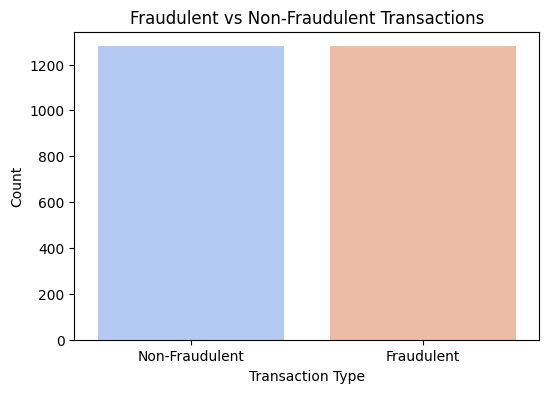

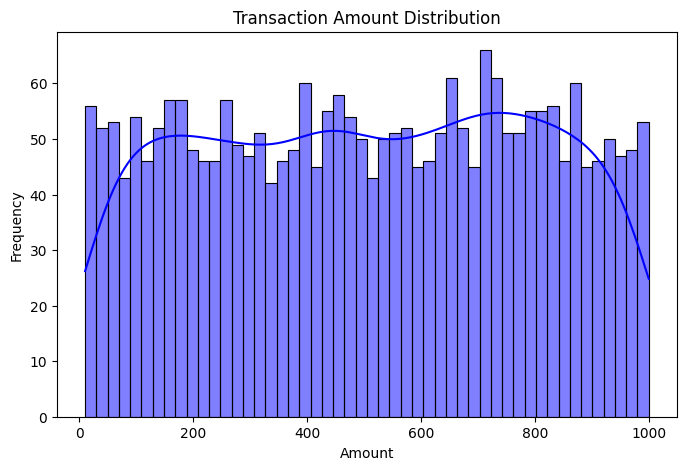

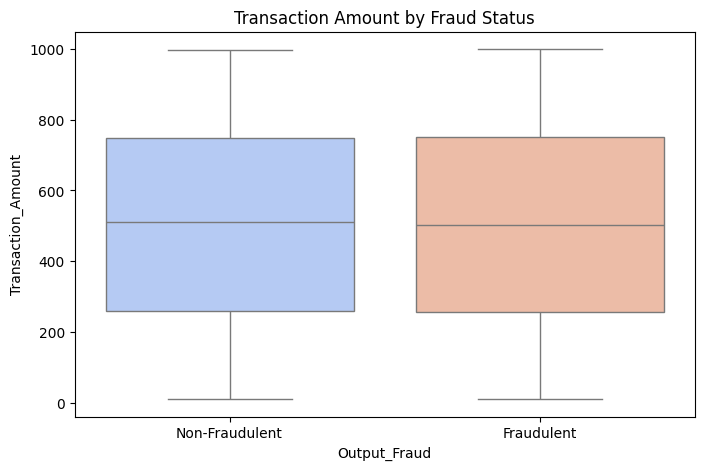

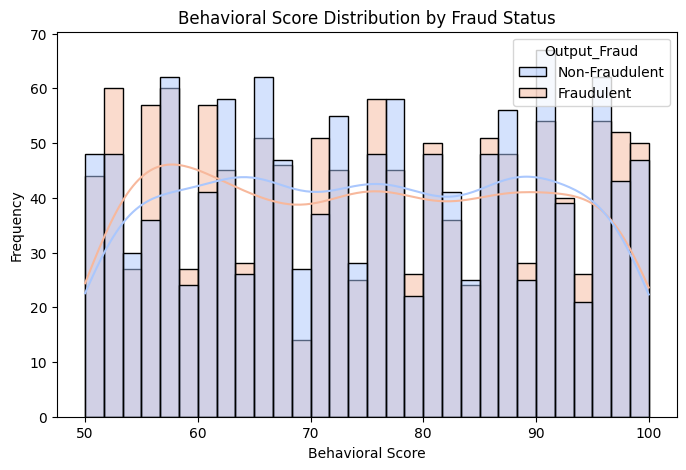


Fraudulent Transactions Percentage:
Output_Fraud
Non-Fraudulent    50.0
Fraudulent        50.0
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "/content/transaction_data_balanced.csv"  # Update path if needed
df = pd.read_csv(file_path)

# Display basic info and first few rows
print("Dataset Info:")
df.info()
print("\nFirst 5 Rows:")
print(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Count of Fraudulent vs. Non-Fraudulent transactions
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Output_Fraud', palette='coolwarm')
plt.title("Fraudulent vs Non-Fraudulent Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

# Transaction amount distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Transaction_Amount'], bins=50, kde=True, color='blue')
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Fraudulent transactions by transaction amount
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Output_Fraud', y='Transaction_Amount', palette='coolwarm')
plt.title("Transaction Amount by Fraud Status")
plt.show()

# Behavioral score distribution by fraud status
plt.figure(figsize=(8, 5))
sns.histplot(df, x='Behavioral_Score', hue='Output_Fraud', bins=30, kde=True, palette='coolwarm')
plt.title("Behavioral Score Distribution by Fraud Status")
plt.xlabel("Behavioral Score")
plt.ylabel("Frequency")
plt.show()

# Percentage of fraudulent transactions
fraud_percentage = df['Output_Fraud'].value_counts(normalize=True) * 100
print("\nFraudulent Transactions Percentage:")
print(fraud_percentage)


In [ ]:
df.head()

,Transaction_ID,Cardholder_Name,Card_Number,Transaction_Amount,Transaction_Date,Device_Type,IP_Address,Location,Behavioral_Score,Security_Features,Historical_Fraudulent_Flag,External_Data_Risk_Score,Output_Fraud
0,TXN03633,Charlie Davis,**** **** **** 1551,959.52,2024-08-19,Tablet,192.168.222.234,"Berlin, Germany",68,OTP Verification,False,28,Non-Fraudulent
1,TXN00475,Bob Johnson,**** **** **** 7708,531.05,2024-06-17,Desktop,192.168.68.18,"London, UK",79,Biometric,True,67,Fraudulent
2,TXN00070,John Doe,**** **** **** 2223,689.77,2024-06-03,Tablet,192.168.12.183,"New York, USA",99,Biometric,False,57,Non-Fraudulent
3,TXN00322,John Doe,**** **** **** 3674,161.44,2025-01-19,Mobile,192.168.67.142,"Los Angeles, USA",99,OTP Verification,False,76,Fraudulent
4,TXN00302,Jane Smith,**** **** **** 8292,11.55,2024-07-25,Tablet,192.168.213.218,"Berlin, Germany",87,3D Secure,False,81,Fraudulent


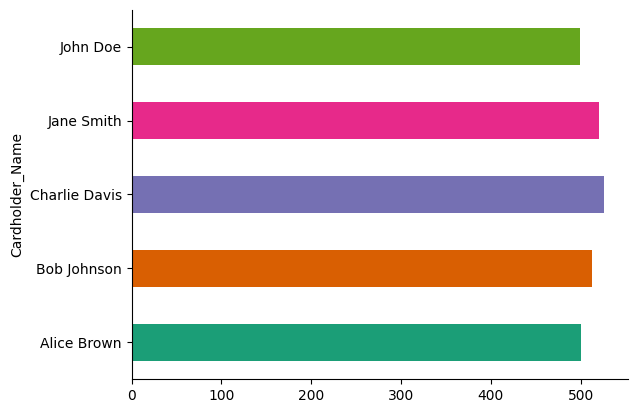

In [ ]:
# @title Cardholder_Name

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Cardholder_Name').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
import pandas as pd
import numpy as np

# Define number of samples
num_samples = 50000

# Generate synthetic data
data = {
    "Transaction_Details": np.random.randint(100000, 999999, num_samples),
    "Cardholder_Information": np.random.choice(["Verified", "Unverified"], num_samples),
    "Device_and_Network_Information": np.random.choice(["Secure", "Compromised"], num_samples),
    "Historical_Data": np.random.uniform(10, 1000, num_samples),  # Transaction history in USD
    "Behavioral_Data": np.random.uniform(0, 1, num_samples),  # Fraud risk score
    "Security_Features": np.random.choice(["Enabled", "Disabled"], num_samples),
    "External_Data": np.random.choice(["High Risk", "Low Risk", "Moderate Risk"], num_samples),
    "Output_Fraud": np.random.choice([0, 1], num_samples, p=[0.85, 0.15])  # 15% fraud cases
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Save dataset as CSV
df.to_csv("synthetic_fraud_data.csv", index=False)

print("Synthetic dataset with 50,000 rows created: synthetic_fraud_data.csv")


Synthetic dataset with 50,000 rows created: synthetic_fraud_data.csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import joblib

# Load the dataset
file_path = "/content/synthetic_fraud_data.csv"  # Update path if needed
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Transaction_Details,Cardholder_Information,Device_and_Network_Information,Historical_Data,Behavioral_Data,Security_Features,External_Data,Output_Fraud
0,985453,Verified,Secure,146.937474,0.036865,Disabled,High Risk,0
1,888245,Verified,Secure,371.502064,0.677997,Disabled,Low Risk,0
2,132868,Unverified,Compromised,754.666159,0.750095,Disabled,Low Risk,0
3,454733,Unverified,Secure,352.127293,0.645470,Enabled,High Risk,1
4,829225,Verified,Secure,793.780557,0.048887,Enabled,Moderate Risk,0


In [ ]:
df.columns

Index(['Transaction_Details', 'Cardholder_Information',
       'Device_and_Network_Information', 'Historical_Data', 'Behavioral_Data',
       'Security_Features', 'External_Data', 'Output_Fraud'],
      dtype='object')

In [ ]:
['Transaction_Details', 'Cardholder_Information',
       'Device_and_Network_Information', 'Historical_Data', 'Behavioral_Data',
       'Security_Features', 'External_Data', 'Output_Fraud']

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import joblib

# Load the dataset
file_path = "/content/synthetic_fraud_data.csv"  # Update path if needed
df = pd.read_csv(file_path)

# Selecting relevant features
features = ['Transaction_Details', 'Cardholder_Information',
       'Device_and_Network_Information', 'Historical_Data', 'Behavioral_Data',
       'Security_Features', 'External_Data', 'Output_Fraud']
target = 'Output_Fraud'

# Encoding categorical variables
for col in features:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])

X = df[features]
y = df[target]

# Splitting data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardizing numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
roc_score = roc_auc_score(y_test, y_pred_prob)
print("\nModel Accuracy:", accuracy)
print("ROC AUC Score:", roc_score)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Saving the model and scaler
joblib.dump(model, "fraud_detection_model.pkl")
joblib.dump(scaler, "scaler.pkl")

# Example: Assign Fraud Probability Score to test transactions
X_test = pd.DataFrame(X_test, columns=features)
X_test['Fraud_Probability'] = y_pred_prob
X_test['Predicted_Fraud'] = y_pred

# Saving the output with fraud probability scores
X_test.to_csv("fraud_predictions.csv", index=False)



Model Accuracy: 1.0
ROC AUC Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8500
           1       1.00      1.00      1.00      1500

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

